In [16]:
import numpy as np

import matplotlib.pyplot as plt

In [36]:
def wavefunctiom_hydrogen(r,θ, a = 1, z = 1):
    p = (z*r)/a
    R_31 = (1/27)*((2*z)/(3*a))**(3/2) *p*(6-p)*np.exp(-p/3)
    Y_10 = np.sqrt(3 / (4 * np.pi)) * np.cos(θ)
    wavefunction = R_31 * Y_10
    return wavefunction 

In [37]:
r = np.linspace(0,25,200)


Radial wavefuncton

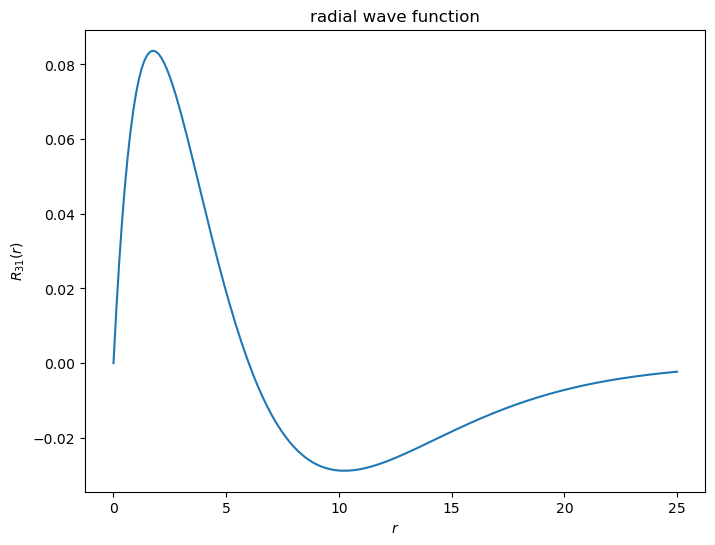

In [42]:

a = 1;
z = 1 
p = (z*r)/a
R_31 = (1/27)*((2*z)/(3*a))**(3/2) *p*(6-p)*np.exp(-p/3)

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(r, R_31)
ax.set_xlabel('$r$')
ax.set_ylabel('$R_{31} (r)$')
ax.set_title('radial wave function')

plt.show()

In [19]:
x = np.linspace(-15, 15, 200)
z = np.linspace(-15, 15, 200)
X, Z = np.meshgrid(x, z)

In [20]:
r = np.sqrt(X**(2) + Z**(2))
θ = np.arccos(Z/r)


In [21]:
Phi = wavefunctiom_hydrogen(r,θ)
Phi

array([[ 0.00190916,  0.00196421,  0.00202046, ...,  0.00202046,
         0.00196421,  0.00190916],
       [ 0.00194447,  0.00200073,  0.00205822, ...,  0.00205822,
         0.00200073,  0.00194447],
       [ 0.00197985,  0.00203732,  0.00209606, ...,  0.00209606,
         0.00203732,  0.00197985],
       ...,
       [-0.00197985, -0.00203732, -0.00209606, ..., -0.00209606,
        -0.00203732, -0.00197985],
       [-0.00194447, -0.00200073, -0.00205822, ..., -0.00205822,
        -0.00200073, -0.00194447],
       [-0.00190916, -0.00196421, -0.00202046, ..., -0.00202046,
        -0.00196421, -0.00190916]], shape=(200, 200))

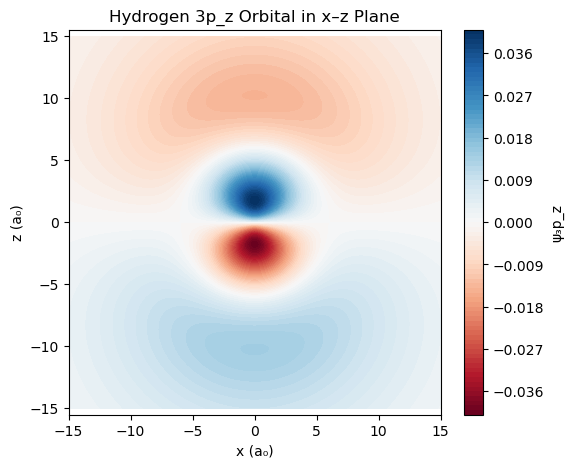

In [22]:
plt.figure(figsize=(6,5))
plt.contourf(X, Z, Phi, levels=100, cmap='RdBu')
plt.colorbar(label='ψ₃p_z')
plt.xlabel('x (a₀)')
plt.ylabel('z (a₀)')
plt.title('Hydrogen 3p_z Orbital in x–z Plane')
plt.axis('equal')
plt.show()

Q2.C


In [23]:
def R31(r, z=1, a=1):
    p = (z*r)/a
    return (1/27)*((2*z)/(3*a))**(3/2) * p*(6-p)*np.exp(-p/3)


In [24]:
def dR31_dr(r, z=1, a=1):
    p = (z*r)/a
    dp_dr = z/a

    # derivative of p(6-p)
    d_term = (6 - p)*dp_dr + p*(-dp_dr)

    prefactor = (1/27)*((2*z)/(3*a))**(3/2)
    exp_term = np.exp(-p/3)

    # full derivative using product rule
    return prefactor * (d_term * exp_term + p*(6-p)*exp_term * (-1/3)*(dp_dr))


Bisection Method


In [25]:
def bisection_with_errors(f, a, b, tol=1e-10):
    fa = f(a); fb = f(b)
    if fa * fb > 0:
        raise ValueError("Root not bracketed")

    errors = []
    iterations = []

    i = 0
    while (b - a) > tol:
        i += 1
        m = 0.5*(a + b)
        fm = f(m)

        errors.append(b - a)   # store error
        iterations.append(i)   # store iteration count

        if fa * fm < 0:
            b = m
            fb = fm
        else:
            a = m
            fa = fm

    return 0.5*(a + b), errors, iterations



Newton Raphson Method

In [26]:
def newton_with_errors(f, df, x0, tol=1e-10, maxiter=50):
    x = x0
    errors = []
    iterations = []

    for k in range(maxiter):
        fx = f(x)
        dfx = df(x)
        if abs(dfx) < 1e-12:
            break

        x_new = x - fx/dfx
        err = abs(x_new - x)

        errors.append(err)     # Store Newton error
        iterations.append(k+1)

        if err < tol:
            return x_new, errors, iterations

        x = x_new

    return x, errors, iterations



In [27]:
root_bis, err_bis, it_bis = bisection_with_errors(R31, 2.5, 7.5)
root_new, err_new, it_new = newton_with_errors(R31, dR31_dr, 2.5)


Q1.D

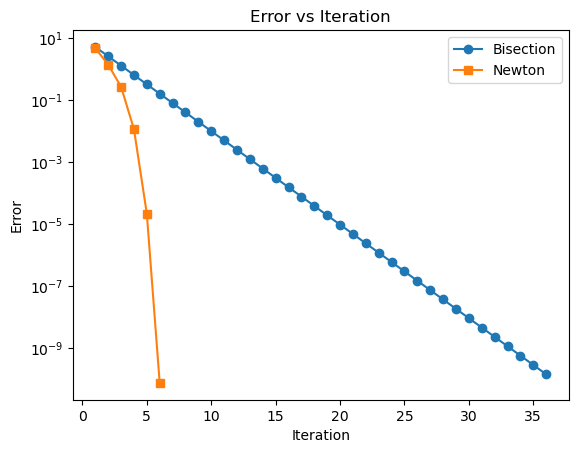

In [28]:
plt.figure()
plt.semilogy(it_bis, err_bis, 'o-', label='Bisection')
plt.semilogy(it_new, err_new, 's-', label='Newton')
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error vs Iteration")
plt.legend()
plt.show()


In [29]:
def prepare_loglog(errors):
    eps_i = np.array(errors[:-1])
    eps_ip1 = np.array(errors[1:])
    return eps_i, eps_ip1


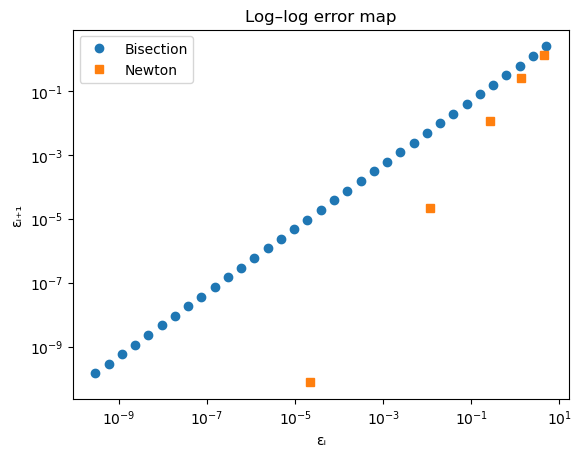

In [30]:
eps_bis_i, eps_bis_ip1 = prepare_loglog(err_bis)
eps_new_i, eps_new_ip1 = prepare_loglog(err_new)

plt.figure()
plt.loglog(eps_bis_i, eps_bis_ip1, 'o', label='Bisection')
plt.loglog(eps_new_i, eps_new_ip1, 's', label='Newton')
plt.xlabel('εᵢ')
plt.ylabel('εᵢ₊₁')
plt.title('Log–log error map')
plt.legend()
plt.show()


2.A

In [31]:

class Atoms:
    def __init__(self, positions):
        """
        positions: numpy array of shape (N, 3)
        """
        self.positions = np.array(positions)

    def set_positions(self, new_positions):
        """Update atomic positions"""
        self.positions = np.array(new_positions)

    def get_pairwise_distances(self):
        """
        Returns a vector of all unique pairwise distances r_ij (i < j)
        """
        pos = self.positions
        N = len(pos)
        distances = []

        for i in range(N):
            for j in range(i+1, N):
                rij = np.linalg.norm(pos[i] - pos[j])
                distances.append(rij)

        return np.array(distances)


In [32]:

class Atoms:
    def __init__(self, positions):
        """
        positions: numpy array of shape (N, 3)
        """
        self.positions = np.array(positions)

    def set_positions(self, new_positions):
        """Update atomic positions"""
        self.positions = np.array(new_positions)

    def get_pairwise_distances(self):
        """
        Returns a vector of all unique pairwise distances r_ij (i < j)
        """
        pos = self.positions
        N = len(pos)
        distances = []

        for i in range(N):
            for j in range(i+1, N):
                rij = np.linalg.norm(pos[i] - pos[j])
                distances.append(rij)

        return np.array(distances)


2.B

In [33]:
class LennardJonesCalculator:
    def __init__(self, epsilon, sigma):
        self.epsilon = epsilon    # in meV
        self.sigma = sigma        # in Å

    def calculate_energy(self, atoms):
        """
        Compute total Lennard-Jones energy for the cluster
        """
        distances = atoms.get_pairwise_distances()
        eps = self.epsilon
        sig = self.sigma

        # LJ potential for each distance
        lj_terms = 4 * eps * ((sig/distances)**12 - (sig/distances)**6)

        # Total energy
        return np.sum(lj_terms)


2.C

In [34]:
# Lennard-Jones parameters for Argon
epsilon = 8.0     # meV
sigma = 3.54      # Å

# Create calculator
lj = LennardJonesCalculator(epsilon, sigma)

# Linear chain coordinates
positions_linear = [
    [0.0, 0.0, 0.0],
    [4.0, 0.0, 0.0],
    [8.0, 0.0, 0.0],
    [12.0, 0.0, 0.0]
]

# Square coordinates
positions_square = [
    [0.0, 0.0, 0.0],
    [4.0, 0.0, 0.0],
    [0.0, 4.0, 0.0],
    [4.0, 4.0, 0.0]
]

# Create Atoms objects
atoms_linear = Atoms(positions_linear)
atoms_square = Atoms(positions_square)

# Compute energies
E_linear = lj.calculate_energy(atoms_linear)
E_square = lj.calculate_energy(atoms_square)

print("Lennard-Jones Energy (Linear Chain):", E_linear, "meV")
print("Lennard-Jones Energy (Square):      ", E_square, "meV")


Lennard-Jones Energy (Linear Chain): -24.461288058820024 meV
Lennard-Jones Energy (Square):       -35.56399810388073 meV
